# 04. Auditing Real Noise

**The question.** Every ER paper needs dirty data, and almost every one *assumes* what the dirt
looks like: a typo rate here, a missing-value rate there, borrowed from a generator whose
defaults trace back decades. This lab refuses the assumption. Before the calibrated dirt machine
(notebook 05) fabricates a single corrupted record, this notebook measures — on real NC voter
records, same person, two years apart — **which noise channels actually fire, on which fields,
how often, and on whom** (NSE-01). The measured mix is the target the generator must reproduce
and the fidelity yardstick every existing generator gets scored against (NSE-02).

**What this notebook settles.** Four things: (1) the **audit-applicability contract** — what a
corpus must provide before this audit is even meaningful (a stable person key + at least two
temporal versions) — together with the central caveat about what same-key diffs can and cannot
measure; (2) the NSE-01 conjecture card, pre-registered before any classification runs; (3) the
measured per-field × per-category prevalence table with Wilson 95% intervals, registered as
`nse01_channel_prevalence`, plus the category-mix and headline-channel figures; (4) the
per-group exposure analysis — name-change prevalence by race and by sex, fitted into an
`ExposureModel` and registered as `nse01_exposure_model` — the group-correlated structure that
generic generators (pseudopeople's column noise) structurally cannot express.

In [1]:
import time

import jellyfish
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.noise.audit import CATEGORIES, classify_pair_diffs, prevalence
from er_lab.noise.channels import fetch_lexicon, load_lexicon
from er_lab.noise.exposure import ExposureModel
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v21-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The substrate arrives through `corpus_registry` (county subset at smoke/mid, statewide at
target — notebook 01's decision, not ours), so the only size dial here is **how many aligned
pairs the audit classifies**: at smoke, a seeded subsample keeps the 4-CPU container inside its
~15-minute budget; at mid and target every aligned pair is audited — same cells, `None` budget.
The scope label is stamped into both artifacts so no downstream reader can mistake a
county-subset subsample for the statewide measurement.

In [3]:
TIER = str(cfg.run.tier)
SIZES = {"smoke": 120_000, "mid": None, "target": None, "analytical": 120_000}  # pairs; None=all
AUDIT_SCOPE = {
    "smoke": "county_subset_subsample",
    "mid": "county_subset_full",
    "target": "statewide_full",
    "analytical": "county_subset_subsample",
}[TIER]
N_EXAMPLES = 3  # masked example rows displayed per category

DATA_ROOT = REPO_ROOT  # corpus_registry paths are repo-root-relative
print(f"tier={TIER}: audit pairs budget = {SIZES.get(TIER)}, scope label = '{AUDIT_SCOPE}'")

tier=smoke: audit pairs budget = 120000, scope label = 'county_subset_subsample'


## 1. When is this audit even allowed? The applicability contract

The trick this notebook runs on — *diff the same person against themselves at two points in
time* — is not available on an arbitrary corpus. It requires exactly two things, and both must
be checked, not assumed:

1. **A stable person key** that means the same person in every version. Here: `ncid`, the
   statewide registrant key — whose right to be trusted was itself audited in notebook 03
   (MET-05: duplication decomposed against registration history, overlay suspects bounded, a
   preliminary pass at county-subset scope), with duplicated-key rows excluded from the join
   upstream (`align_pair`, notebook 01).
2. **At least two temporal versions** of the records under that key. Here: two New-Year's
   snapshots two years apart.

A corpus offering only one version, or only an unstable within-file id, simply cannot be
audited this way — notebook 18's adaptation checklist carries this contract verbatim.

> ### ⚠ The central caveat — read before believing any number below
>
> Same-NCID diffs measure **changes over two years** — moves, marriages and divorces (legal
> name changes), clerical corrections, coding drift — **not raw entry errors**. An entry error
> is visible here only when exactly one snapshot carries it; a typo faithfully copied into both
> snapshots is *invisible by construction*. So the prevalence measured below calibrates the
> **temporal-drift noise axis** directly, and bounds entry-error channels (typo, OCR) only from
> below. And notebook 03 §2b showed the aligned substrate excludes duplicated NCIDs —
> re-registrants, the mobile — so every rate here is a **stable-registrant lower bound**. This
> caveat is carried into both artifacts' meta and repeated at every interpretation.

In [4]:
# The inherited substrate: notebook 01's corpus_registry (hard-fails if 01 has not run at tier).
corpus, corpus_meta = registry.load("corpus_registry", tier=cfg.run.tier)
nc_info = corpus["nc_snapshots"]
SNAP_A, SNAP_B = nc_info["a"]["date"], nc_info["b"]["date"]
aligned_path = DATA_ROOT / nc_info["aligned_path"]
align_stats = nc_info["align_stats"]
elapsed_years = (pd.Timestamp(SNAP_B) - pd.Timestamp(SNAP_A)).days / 365.25

contract = {
    "stable_key": (
        "ncid — statewide registrant key; duplicated-ncid rows excluded upstream "
        "(align_pair, NB01); key error itself audited by MET-05 (NB03)"
    ),
    "temporal_versions": f"2 snapshots: {SNAP_A} and {SNAP_B} ({elapsed_years:.2f} years apart)",
    "measures": (
        "CHANGES over the window (moves, name changes, corrections, coding drift) — "
        "NOT raw entry errors; see the central caveat"
    ),
}
assert SNAP_A != SNAP_B, "audit needs two distinct temporal versions"
assert align_stats["pairs"] > 0, "audit needs a non-empty aligned substrate"
print(f"snapshots     : {SNAP_A} ({nc_info['a']['n_records']} records) / "
      f"{SNAP_B} ({nc_info['b']['n_records']} records)")
print(f"counties      : {nc_info['counties']} (None = statewide)")
print(f"aligned pairs : {align_stats['pairs']} (dup ncids excluded: "
      f"a={align_stats['dup_ncids_a']}, b={align_stats['dup_ncids_b']})")
print("\napplicability contract (carried into artifact meta):")
for key, val in contract.items():
    print(f"  {key:>17}: {val}")

snapshots     : 20240101 (423135 records) / 20260101 (447450 records)
counties      : [68] (None = statewide)
aligned pairs : 391257 (dup ncids excluded: a=13226, b=15775)

applicability contract (carried into artifact meta):
         stable_key: ncid — statewide registrant key; duplicated-ncid rows excluded upstream (align_pair, NB01); key error itself audited by MET-05 (NB03)
  temporal_versions: 2 snapshots: 20240101 and 20260101 (2.00 years apart)
           measures: CHANGES over the window (moves, name changes, corrections, coding drift) — NOT raw entry errors; see the central caveat


In [5]:
#: The caveat as a constant — registered verbatim in BOTH artifacts' meta below.
CAVEAT = (
    "Same-NCID diffs across two snapshots measure CHANGES over the elapsed window — moves, "
    "legal name changes (marriage/divorce), clerical corrections, coding drift — NOT raw "
    "entry-error rates. An entry error is visible only when exactly one snapshot carries it; an "
    "error stable across both snapshots is invisible by construction. These rates calibrate the "
    "temporal-drift noise axis directly and bound typo/OCR entry-error channels only from below. "
    "Substrate selection (NB03 sec 2b): duplicated ncids are excluded, biasing the substrate "
    "toward stable registrants — every rate is a lower bound for mobile subpopulations."
)
print(f"caveat constant: {len(CAVEAT)} chars, registered in both artifact metas")

caveat constant: 614 chars, registered in both artifact metas


## 2. The conjecture, before the numbers

What *should* two years of reality do to a voter record? The literature's default generators
say: sprinkle typos. The lab's conjecture says reality is different in kind — people **move**
far more often than clerks mistype, and when a name does change it changes **wholesale** (a
different surname after marriage), not by one keystroke; and that name-change exposure is
carried unevenly across demographic groups. The prediction below is informed by notebook 03's
public preview (the given/family diff mix it computed while hunting overlays) — pre-registration
means *stated before this notebook's measurement*, not feigned ignorance of upstream artifacts.

In [6]:
P1_DOMINANCE_FACTOR = 3.0  # street wholesale >= 3x every name-field change category
P2_FAMILY_TYPO_MAX = 0.01  # family_name typo rate < 1% of pairs
P3_MULT_RATIO_MIN = 2.0  # fitted F multiplier >= 2x M multiplier on family-name change
_ = conjecture_card(
    card_id="NSE-01",
    conjecture=(
        "Real two-year record drift is dominated by wholesale replacement of address-bearing "
        "fields (people move), not by character-level noise; name fields change rarely and, "
        "when they do, predominantly by wholesale replacement (legal name change) rather than "
        "typo; and family-name-change exposure is group-correlated (strongly by sex)."
    ),
    pressure=(
        "reality itself: two years of life events plus county data-entry practice between two "
        "snapshots of the same registrants, at this tier's scope"
    ),
    property=(
        "measured per-field diff-category mix (noise.audit taxonomy: missing_gain/loss, swap, "
        "format_drift, nickname, typo, wholesale) with Wilson 95% CIs, and per-group "
        "(race, sex) rates on the name-change channels"
    ),
    metric=(
        "nse01_channel_prevalence rates per (field, category); nse01_exposure_model per-group "
        "multipliers fitted from the same counts"
    ),
    prediction=(
        "P1: street wholesale-change rate exceeds EVERY change category on every name field "
        "(given/middle/family) by >= 3x. P2: family_name typo rate < 1% of pairs (expect well "
        "under 0.1%). P3: family-name wholesale rate for sex F exceeds sex M with "
        "non-overlapping Wilson 95% CIs, and the fitted F exposure multiplier is >= 2x the M "
        "multiplier. Scope: changes over two years at this tier's substrate, per the caveat."
    ),
    registry=registry,
)

### Conjecture card `NSE-01`

| | |
|---|---|
| **Conjecture** | Real two-year record drift is dominated by wholesale replacement of address-bearing fields (people move), not by character-level noise; name fields change rarely and, when they do, predominantly by wholesale replacement (legal name change) rather than typo; and family-name-change exposure is group-correlated (strongly by sex). |
| **Pressure (dial)** | reality itself: two years of life events plus county data-entry practice between two snapshots of the same registrants, at this tier's scope |
| **Embedding property** | measured per-field diff-category mix (noise.audit taxonomy: missing_gain/loss, swap, format_drift, nickname, typo, wholesale) with Wilson 95% CIs, and per-group (race, sex) rates on the name-change channels |
| **System metric** | nse01_channel_prevalence rates per (field, category); nse01_exposure_model per-group multipliers fitted from the same counts |
| **Pre-registered prediction** | P1: street wholesale-change rate exceeds EVERY change category on every name field (given/middle/family) by >= 3x. P2: family_name typo rate < 1% of pairs (expect well under 0.1%). P3: family-name wholesale rate for sex F exceeds sex M with non-overlapping Wilson 95% CIs, and the fitted F exposure multiplier is >= 2x the M multiplier. Scope: changes over two years at this tier's substrate, per the caveat. |

*Immutable — sha256 `1254475b25e9`; registered before the affected runs, never edited (PLAN §5).*


## 3. A taxonomy for diffs — and the nickname lexicon

`noise.audit.classify_pair_diffs` sorts every (pair, field) difference into a fixed taxonomy,
tested in decision order so each diff lands in exactly one bin: `identical` →
`missing_gain`/`missing_loss` (present on one side only) → `swap` (value exchanged with another
name field of the same record) → `format_drift` (same content, different format — punctuation,
USPS abbreviations, date formats) → `nickname` (given names sharing a lexicon class) → `typo`
(Levenshtein ≤ 2) → `wholesale` (everything else). The audit module is deliberately independent
of the generator channels it will later score — no shared implementation, so NSE-02's fidelity
comparison is not grading the generator against itself.

The nickname category needs the carltonnorthern lexicon (fetched below; idempotent). Standing
limitation, carried on every nickname claim: the lexicon is **English-centric with documented
provenance bias** (PLAN §4, DATA_GOVERNANCE.md) — nickname prevalence for names outside its
coverage is undercounted, and that undercount is not demographically neutral.

In [7]:
lexicon_csv = fetch_lexicon(data_root=str(DATA_ROOT / "data"))
lexicon_raw = load_lexicon(str(DATA_ROOT / "data"))

# WORKAROUND (package bug, reported in-notebook rather than patching src/): the upstream
# names.csv changed format from "canonical,nick1,nick2,..." to one "name1,has_nickname,name2"
# triple per line with a header row. load_lexicon parses the old format, so every entry gains a
# spurious 'has_nickname' variant and the header row becomes a bogus 'name1' entry. Harmless for
# classification (no real given name is 'has_nickname'), but the counts would lie — so sanitize.
drifted = "name1" in lexicon_raw or any("has_nickname" in v for v in lexicon_raw.values())
lexicon = {
    canon: {v for v in variants if v not in ("has_nickname", "relationship")}
    for canon, variants in lexicon_raw.items()
    if canon != "name1"
}
lexicon = {c: v for c, v in lexicon.items() if v}
print(f"lexicon file: {lexicon_csv}")
print(f"upstream format drift detected: {drifted} "
      f"(raw entries {len(lexicon_raw)} -> sanitized {len(lexicon)})")
print(f"sanitized lexicon: {len(lexicon)} canonical names, "
      f"{sum(len(v) for v in lexicon.values())} variant links "
      "(English-centric; provenance bias carried on every nickname claim)")

lexicon file: /home/user/embedding-based-entity-resolution/data/lexicons/names.csv
upstream format drift detected: True (raw entries 1233 -> sanitized 1232)
sanitized lexicon: 1232 canonical names, 2827 variant links (English-centric; provenance bias carried on every nickname claim)


## 4. The audit substrate at this tier

Nine text roles are audited — the three name parts, the three street-address parts
(`house_number`, `street`, `unit` — NC ships the address pre-parsed), `city`, `zip`, and
`phone`. At smoke a seeded subsample of the aligned pairs is drawn (uniform, without
replacement — pairs are exchangeable rows here, so no entity-completeness concern arises); at
mid/target the budget is `None` and every aligned pair is classified — one code path.

One denominator honesty note before any rate: `prevalence` divides by **all audited pairs**,
and `identical` includes missing-on-both-sides. For a sparsely populated field that convention
makes change rates look tiny — so the populated-on-both-sides share is printed per field below
and stored in the artifact meta. Read `phone` rates against its populated share, not against 1.

In [8]:
FIELDS = ["given_name", "middle_name", "family_name", "house_number", "street", "unit",
          "city", "zip", "phone"]
LOAD_COLS = ["ncid", "race_a", "sex_a"] + [f"{f}_{s}" for f in FIELDS for s in ("a", "b")]
t0 = time.time()
aligned = pd.read_parquet(aligned_path, columns=LOAD_COLS)
assert len(aligned) == align_stats["pairs"], "aligned parquet drifted from corpus_registry stats"

n_budget = SIZES.get(TIER, SIZES["smoke"])
rng = np.random.default_rng(cfg.run.seed)
if n_budget is not None and n_budget < len(aligned):
    idx = np.sort(rng.choice(len(aligned), size=n_budget, replace=False))
    sub = aligned.iloc[idx].reset_index(drop=True)
    sampling = f"seeded uniform subsample without replacement (seed={int(cfg.run.seed)})"
else:
    sub = aligned.reset_index(drop=True)
    sampling = "all aligned pairs (no subsampling at this tier)"
print(f"loaded {len(aligned)} aligned pairs in {time.time() - t0:.1f}s; "
      f"auditing {len(sub)} ({sampling})")


def present(s: pd.Series) -> pd.Series:
    """Same missing semantics as noise.audit: NA or whitespace-only counts as missing."""
    return s.notna() & (s.astype("string").str.strip() != "")


pop_both = {
    f: float((present(sub[f + "_a"]) & present(sub[f + "_b"])).mean()) for f in FIELDS
}
print("\npopulated on BOTH sides (the real denominator context per field):")
for f in FIELDS:
    print(f"  {f:>14}: {pop_both[f]:8.2%}")

loaded 391257 aligned pairs in 1.4s; auditing 120000 (seeded uniform subsample without replacement (seed=17))



populated on BOTH sides (the real denominator context per field):
      given_name:   99.99%
     middle_name:   92.28%
     family_name:  100.00%
    house_number:  100.00%
          street:   99.98%
            unit:   28.85%
            city:  100.00%
             zip:   99.98%
           phone:    0.22%


## 5. Classifying every diff

One call does the work; the timer is printed because the statewide target run scales linearly
in pairs × fields and the node placard at the end of section 8 needs an honest coefficient.

In [9]:
t0 = time.time()
long_df = classify_pair_diffs(sub, fields=FIELDS, lexicon=lexicon)
classify_secs = time.time() - t0
print(f"classified {len(sub)} pairs x {len(FIELDS)} fields in {classify_secs:.1f}s "
      f"({len(sub) * len(FIELDS) / max(classify_secs, 1e-9):,.0f} cell-diffs/s)")

# classify emits len(FIELDS) blocks, each in sub row order -> per-field category arrays align
# positionally with sub; everything downstream (examples, exposure) leans on this contract.
cat_of = {f: long_df.loc[long_df["field"] == f, "category"].to_numpy() for f in FIELDS}
changed_share = {f: float((cat_of[f] != "identical").mean()) for f in FIELDS}
print("\nshare of pairs with ANY change, per field (two-year window — changes, not entry errors):")
for f, share in sorted(changed_share.items(), key=lambda kv: -kv[1]):
    print(f"  {f:>14}: {share:8.3%}")

classified 120000 pairs x 9 fields in 3.7s (289,340 cell-diffs/s)



share of pairs with ANY change, per field (two-year window — changes, not entry errors):
    house_number:   1.606%
          street:   1.532%
            unit:   1.007%
             zip:   0.853%
            city:   0.508%
     middle_name:   0.393%
     family_name:   0.304%
      given_name:   0.114%
           phone:   0.080%


### What the categories look like on real pairs (masked)

A few specimens per interesting category, so the taxonomy is not an abstraction. Display
masking per `DATA_GOVERNANCE.md` — the classification above ran on verbatim values, but what
renders here is: name fields as initial+length, streets as first character + street-type token,
house numbers/units as length only, phone as presence, NCIDs truncated. City and zip display
verbatim (coarse geography, the same convention notebook 03 used). The `lev` column is the
case-insensitive Levenshtein distance — it shows a `typo` really is 1–2 edits and a
`wholesale` really is not, without exposing the strings.

In [10]:
NAME_FIELDS = ("given_name", "middle_name", "family_name")
EXAMPLE_PICKS = [
    ("family_name", "wholesale"), ("family_name", "typo"), ("given_name", "nickname"),
    ("given_name", "swap"), ("street", "wholesale"), ("zip", "typo"),
    ("middle_name", "missing_gain"), ("phone", "missing_gain"),
]


def mask_value(field: str, v: object) -> str:
    """DATA_GOVERNANCE display masking: initials, lengths, no full streets, no phone digits."""
    if pd.isna(v) or not str(v).strip():
        return "-"
    s = str(v).strip()
    if field in NAME_FIELDS:
        return f"{s[0]}.({len(s)})"
    if field == "street":
        return f"{s[0]}... {s.split()[-1]}"
    if field in ("house_number", "unit"):
        return f"<{len(s)} ch>"
    if field == "phone":
        return "<present>"
    return s  # city / zip: coarse geography, shown verbatim (NB03 convention)


example_rows = []
for f, c in EXAMPLE_PICKS:
    for pos in np.flatnonzero(cat_of[f] == c)[:N_EXAMPLES]:
        row = sub.iloc[int(pos)]
        a, b = row[f + "_a"], row[f + "_b"]
        lev = (jellyfish.levenshtein_distance(str(a).strip().lower(), str(b).strip().lower())
               if present(pd.Series([a])).iloc[0] and present(pd.Series([b])).iloc[0] else pd.NA)
        example_rows.append({
            "ncid": str(row["ncid"])[:4] + "...", "field": f, "category": c,
            "before": mask_value(f, a), "after": mask_value(f, b), "lev": lev,
        })
display(pd.DataFrame(example_rows))

,ncid,field,category,before,after,lev
0,AA14...,family_name,wholesale,W.(7),K.(4),7
1,AK14...,family_name,wholesale,L.(7),H.(4),7
2,AL27...,family_name,wholesale,L.(6),H.(8),7
3,BL29...,family_name,typo,M.(8),M.(8),1
4,DE25...,family_name,typo,J.(6),J.(6),1
5,DE27...,family_name,typo,B.(7),B.(7),1
6,BL15...,given_name,nickname,M.(7),M.(3),4
7,CP39...,given_name,nickname,J.(8),J.(8),1
8,DE13...,given_name,nickname,V.(6),V.(5),1
9,DE32...,given_name,swap,A.(13),A.(9),9


## 6. Prevalence with intervals — the NSE-01 table

The full per-field × per-category table, every rate with its Wilson 95% interval (the same
interval convention as notebooks 01–03), a `scope` column stamped on every row, and the caveat
in the meta. This is the artifact notebook 05 calibrates against and notebook 05's NSE-02
fidelity scoring diffs generators against.

In [11]:
prev = prevalence(long_df)
prev["scope"] = AUDIT_SCOPE
registry.register(
    "nse01_channel_prevalence",
    prev,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "caveat": CAVEAT,
        "applicability_contract": contract,
        "scope": AUDIT_SCOPE,
        "snapshots": [SNAP_A, SNAP_B],
        "window_years": round(elapsed_years, 2),
        "counties": nc_info["counties"],
        "pairs_audited": len(sub),
        "pairs_available": int(align_stats["pairs"]),
        "sampling": sampling,
        "fields": list(FIELDS),
        "categories": list(CATEGORIES),
        "denominator": "all audited pairs; 'identical' includes missing-on-both-sides",
        "populated_both_share": pop_both,
        "nickname_lexicon": {
            "source": "carltonnorthern nicknames (fetched)",
            "canonical": len(lexicon),
            "variant_links": int(sum(len(v) for v in lexicon.values())),
            "upstream_format_drift_workaround": bool(drifted),
            "limitation": "English-centric, documented provenance bias (PLAN §4)",
        },
    },
)
changes = prev[prev["category"] != "identical"].reset_index(drop=True)
print(f"registered nse01_channel_prevalence: {len(prev)} (field x category) rows, "
      f"{len(changes)} change rows shown below")
display(changes)

registered nse01_channel_prevalence: 39 (field x category) rows, 30 change rows shown below


,field,category,n,rate,ci_low,ci_high,scope
0,city,wholesale,610,0.005083,0.004697,0.005502,county_subset_subsample
1,family_name,format_drift,186,0.001550,0.001343,0.001789,county_subset_subsample
2,family_name,swap,4,0.000033,0.000013,0.000086,county_subset_subsample
3,family_name,typo,23,0.000192,0.000128,0.000288,county_subset_subsample
4,family_name,wholesale,152,0.001267,0.001081,0.001485,county_subset_subsample
5,given_name,format_drift,43,0.000358,0.000266,0.000483,county_subset_subsample
6,given_name,missing_loss,1,0.000008,0.000001,0.000047,county_subset_subsample
7,given_name,nickname,10,0.000083,0.000045,0.000153,county_subset_subsample
8,given_name,swap,4,0.000033,0.000013,0.000086,county_subset_subsample
9,given_name,typo,31,0.000258,0.000182,0.000367,county_subset_subsample


### Figure: what changes, per field — and how

The category mix per field (identical excluded — it would drown everything at this timescale).
Bars are shares of *all* audited pairs, so bar length is comparable across fields; the number
at each bar's end is the field's total changed share.

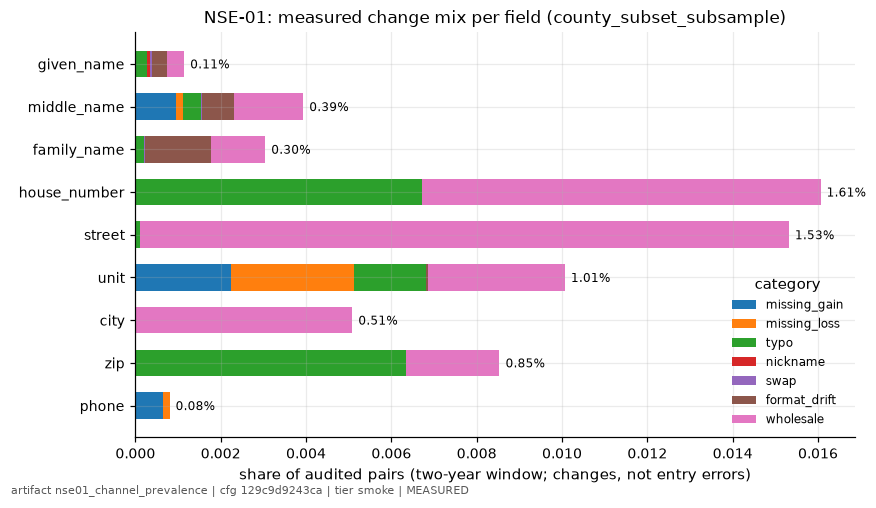

In [12]:
CHANGE_CATS = [c for c in CATEGORIES if c != "identical"]


def draw_mix(ax, df, meta):
    df = df[df["category"] != "identical"]
    left = np.zeros(len(FIELDS))
    for cat in CHANGE_CATS:
        vals = np.array([
            float(df.loc[(df["field"] == f) & (df["category"] == cat), "rate"].sum())
            for f in FIELDS
        ])
        ax.barh(range(len(FIELDS)), vals, left=left, height=0.62, label=cat)
        left += vals
    for i, total in enumerate(left):
        ax.annotate(f"{total:.2%}", (total, i), textcoords="offset points", xytext=(4, -3),
                    fontsize=8)
    ax.set_yticks(range(len(FIELDS)), FIELDS)
    ax.invert_yaxis()
    ax.set_xlabel("share of audited pairs (two-year window; changes, not entry errors)")
    ax.legend(loc="lower right", fontsize=8, title="category")


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="nse01_channel_prevalence",
    draw=draw_mix,
    title=f"NSE-01: measured change mix per field ({AUDIT_SCOPE})",
    figsize=(8.0, 4.6),
)

### Figure: the headline channels, with intervals

The channels the rest of the lab will keep citing, on a log axis with Wilson 95% whiskers.
Headline channels that fired **zero times** cannot appear in the prevalence table (only
observed categories are emitted), so the cell before the figure names them and prints their
one-sided Wilson upper bounds — a zero is a measurement too.

headline channel with ZERO events: street:format_drift — 0/120000 pairs, Wilson 95% upper bound 3.20e-05


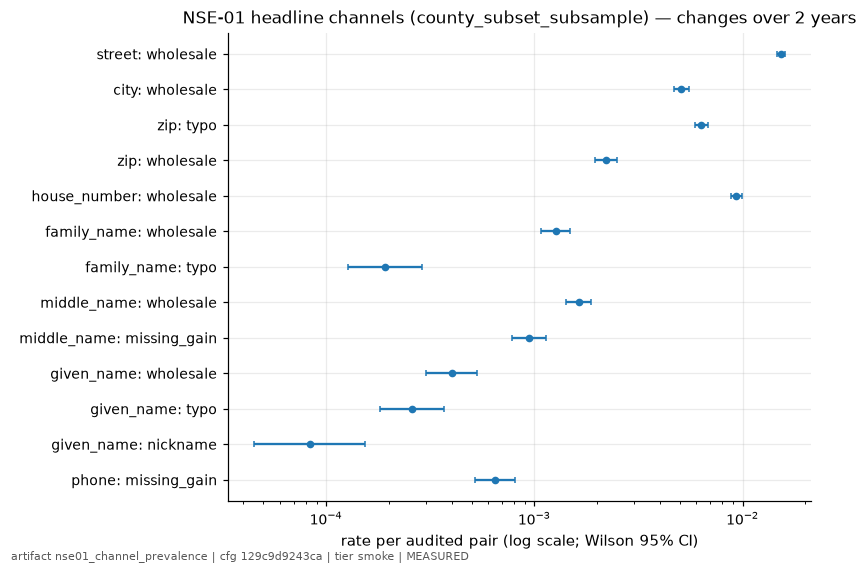

In [13]:
Z95 = float(norm.ppf(0.975))


def wilson_upper(k: int, n: int) -> float:
    """Wilson 95% upper bound (same form as noise.audit's interval)."""
    p, z2 = k / n, Z95 * Z95
    denom = 1.0 + z2 / n
    center = (p + z2 / (2.0 * n)) / denom
    half = Z95 * np.sqrt(p * (1.0 - p) / n + z2 / (4.0 * n * n)) / denom
    return float(min(center + half, 1.0))


HEADLINE = [
    ("street", "wholesale"), ("street", "format_drift"), ("city", "wholesale"),
    ("zip", "typo"), ("zip", "wholesale"), ("house_number", "wholesale"),
    ("family_name", "wholesale"), ("family_name", "typo"), ("middle_name", "wholesale"),
    ("middle_name", "missing_gain"), ("given_name", "wholesale"), ("given_name", "typo"),
    ("given_name", "nickname"), ("phone", "missing_gain"),
]
observed = {(f, c) for f, c in zip(prev["field"], prev["category"])}
for f, c in HEADLINE:
    if (f, c) not in observed:
        print(f"headline channel with ZERO events: {f}:{c} — 0/{len(sub)} pairs, "
              f"Wilson 95% upper bound {wilson_upper(0, len(sub)):.2e}")


def draw_headline(ax, df, meta):
    rows = [(f"{f}: {c}", df[(df["field"] == f) & (df["category"] == c)].iloc[0])
            for f, c in HEADLINE if ((df["field"] == f) & (df["category"] == c)).any()]
    for i, (label, r) in enumerate(rows):
        ax.errorbar(r["rate"], i,
                    xerr=[[r["rate"] - r["ci_low"]], [r["ci_high"] - r["rate"]]],
                    fmt="o", color="C0", capsize=2, markersize=4)
    ax.set_yticks(range(len(rows)), [label for label, _ in rows])
    ax.set_xscale("log")
    ax.invert_yaxis()
    ax.set_xlabel("rate per audited pair (log scale; Wilson 95% CI)")


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="nse01_channel_prevalence",
    draw=draw_headline,
    title=f"NSE-01 headline channels ({AUDIT_SCOPE}) — changes over {elapsed_years:.0f} years",
    figsize=(7.5, 5.2),
)

### Reading the table honestly

Three patterns in the printed numbers deserve interpretation — each with the caveat attached:

- **Address wholesale-change is the dominant channel** — street changes an order of magnitude
  more often than any name field, and when street changes it changes wholesale, not by edits.
  These are overwhelmingly *moves* (true change), which is exactly why they calibrate the
  temporal-drift axis and say nothing about keystroke error.
- **The `zip:typo` and `house_number:typo` bins are not typos.** The taxonomy is lexical: a
  move to a nearby zip, or to a house number sharing most digits, differs in 1–2 characters
  and lands in `typo` by edit distance. For numeric geographic fields the typo/wholesale split
  should be read as near-move/far-move, not error/change — carried into notebook 05's
  calibration notes (a generator must NOT read those bins as keyboard-error rates).
- **`street:format_drift` is absent or near-absent** while notebook 01's raw-form inspection
  showed heavy USPS abbreviation. Both snapshots pass through the same NCSBE standardization,
  so format volatility inside one source is nearly zero — format drift is a *cross-source*
  phenomenon (PRS-01's raw-vs-standardized factor), not a temporal one. A generator wrapping
  this corpus should apply format drift between sources, not between versions.

## 7. Moves are not column noise: address parts change together

Generic generators corrupt columns independently. Reality moves a *person*: house number,
street, zip, and city change in one correlated event. The conditional-change table below
measures that jointness on the same classified pairs and registers it as the supporting
artifact `nse01_address_cochange` — notebook 05's move channel must reproduce joint
replacement, and its fidelity scoring can hold generators to this table.

In [14]:
changed_mask = {f: cat_of[f] != "identical" for f in FIELDS}
cochange_specs = [
    ("street changed", changed_mask["street"], "zip changed", changed_mask["zip"]),
    ("street changed", changed_mask["street"], "city changed", changed_mask["city"]),
    ("street changed", changed_mask["street"], "house_number changed",
     changed_mask["house_number"]),
    ("zip changed", changed_mask["zip"], "street changed", changed_mask["street"]),
    ("family_name wholesale", cat_of["family_name"] == "wholesale",
     "given_name changed", changed_mask["given_name"]),
    ("family_name wholesale", cat_of["family_name"] == "wholesale",
     "street changed", changed_mask["street"]),
]
co_rows = []
for cond_name, cond, event_name, event in cochange_specs:
    n, k = int(cond.sum()), int((cond & event).sum())
    p, z2 = (k / n if n else 0.0), Z95 * Z95
    denom = 1.0 + z2 / max(n, 1)
    center = (p + z2 / (2.0 * max(n, 1))) / denom
    half = Z95 * np.sqrt(p * (1.0 - p) / max(n, 1) + z2 / (4.0 * max(n, 1) ** 2)) / denom
    co_rows.append({
        "condition": cond_name, "event": event_name, "k": k, "n": n, "rate": p,
        "ci_low": max(center - half, 0.0), "ci_high": min(center + half, 1.0),
        "baseline_rate": float(event.mean()), "scope": AUDIT_SCOPE,
    })
cochange = pd.DataFrame(co_rows)
registry.register(
    "nse01_address_cochange", cochange, cfg=cfg, tier=cfg.run.tier,
    meta={"caveat": CAVEAT, "scope": AUDIT_SCOPE, "pairs_audited": len(sub),
          "note": "P(event | condition) vs unconditional baseline — the jointness a per-column "
                  "noise model cannot express; NSE-02 may score generators against it"},
)
display(cochange)
print("read each row as P(event | condition) against its unconditional baseline_rate — "
      "the lift IS the correlated-move structure.")

,condition,event,k,n,rate,ci_low,ci_high,baseline_rate,scope
0,street changed,zip changed,1017,1838,0.553319,0.530503,0.575912,0.008533,county_subset_subsample
1,street changed,city changed,604,1838,0.328618,0.307521,0.350430,0.005083,county_subset_subsample
2,street changed,house_number changed,1803,1838,0.980958,0.973633,0.986276,0.016058,county_subset_subsample
3,zip changed,street changed,1017,1024,0.993164,0.985957,0.996685,0.015317,county_subset_subsample
4,family_name wholesale,given_name changed,12,152,0.078947,0.045736,0.132917,0.001142,county_subset_subsample
5,family_name wholesale,street changed,33,152,0.217105,0.158976,0.289181,0.015317,county_subset_subsample


read each row as P(event | condition) against its unconditional baseline_rate — the lift IS the correlated-move structure.


## 8. Who carries the noise? Group-correlated exposure

The fairness literature's central pre-algorithmic mechanism: identifier quality and volatility
differ **by group**, so noise exposure is group-correlated — and a generator that corrupts
uniformly manufactures a world where error-rate disparities cannot exist (pseudopeople's
column noise is structurally in that world; PLAN §4). NSE-01 therefore measures, for the two
name-change-bearing channels —

- `family_name_change`: family name replaced wholesale (the legal-name-change channel),
- `given_name_variant`: given name replaced wholesale or by a lexicon nickname,

— the per-group rates by NCSBE `race_a` code and by `sex_a` code (side-a labels, the older
snapshot), and fits `ExposureModel.fit_from_prevalence` on each: a group's multiplier is its
rate relative to the pooled rate, so notebook 05 can apply `base_rate × multiplier` per record
while keeping the corpus-level expectation intact. Zero-event groups get multiplier 0 with an
honest upper bound — the display marks them, and the small-print paragraph below says what
they may and may not be used for.

In [15]:
EXPOSURE_CHANNELS = {
    "family_name_change": ("family_name", ("wholesale",)),
    "given_name_variant": ("given_name", ("wholesale", "nickname")),
}
GROUP_COLS = {"race": "race_a", "sex": "sex_a"}

events = pd.DataFrame({
    ch: np.isin(cat_of[field], list(cats)) for ch, (field, cats) in EXPOSURE_CHANNELS.items()
})
for gname, src in GROUP_COLS.items():
    vals = sub[src].astype("string").str.strip()
    events[gname] = vals.mask(vals == "").to_numpy()
n_blank = {g: int(events[g].isna().sum()) for g in GROUP_COLS}
base_rates = {ch: float(events[ch].mean()) for ch in EXPOSURE_CHANNELS}
print(f"blank group labels (excluded from fits, default multiplier 1.0 downstream): {n_blank}")
print("channel base rates (pooled, per audited pair):")
for ch, r in base_rates.items():
    print(f"  {ch:>20}: {r:.5%}")

exposure_rows = []
for ch in EXPOSURE_CHANNELS:
    for gname in GROUP_COLS:
        grp = (events.dropna(subset=[gname]).groupby(gname, observed=True)[ch]
               .agg(k="sum", n="size").reset_index().rename(columns={gname: "group"}))
        grp["rate"] = grp["k"] / grp["n"]
        fit_tbl = grp[["group", "rate", "n"]].rename(columns={"group": gname})
        model = ExposureModel.fit_from_prevalence(fit_tbl)
        overall = float((grp["rate"] * grp["n"]).sum() / grp["n"].sum())
        merged = grp.merge(model.multipliers.rename(columns={gname: "group"}), on="group")
        assert len(merged) == len(grp), "every group must receive a fitted multiplier"
        assert np.allclose(merged["multiplier"], merged["rate"] / overall), (
            "fit_from_prevalence multipliers must equal group rate / pooled rate"
        )
        for _, r in merged.iterrows():
            p, n = float(r["rate"]), int(r["n"])
            z2 = Z95 * Z95
            denom = 1.0 + z2 / n
            center = (p + z2 / (2.0 * n)) / denom
            half = Z95 * np.sqrt(p * (1.0 - p) / n + z2 / (4.0 * n * n)) / denom
            lo, hi = max(center - half, 0.0), min(center + half, 1.0)
            exposure_rows.append({
                "channel": ch, "group_col": gname, "group": str(r["group"]),
                "n": n, "k": int(r["k"]), "rate": p, "ci_low": lo, "ci_high": hi,
                "multiplier": float(r["multiplier"]),
                "mult_ci_low": lo / overall, "mult_ci_high": hi / overall,
                "pooled_rate": overall, "scope": AUDIT_SCOPE,
            })
exposure = pd.DataFrame(exposure_rows).sort_values(
    ["channel", "group_col", "n"], ascending=[True, True, False], ignore_index=True)
display(exposure)

blank group labels (excluded from fits, default multiplier 1.0 downstream): {'race': 0, 'sex': 0}
channel base rates (pooled, per audited pair):
    family_name_change: 0.12667%
    given_name_variant: 0.04833%


,channel,group_col,group,n,k,rate,ci_low,ci_high,multiplier,mult_ci_low,mult_ci_high,pooled_rate,scope
0,family_name_change,race,W,92443,100,0.001082,0.000890,0.001315,0.854011,0.702291,1.038466,0.001267,county_subset_subsample
1,family_name_change,race,B,13588,19,0.001398,0.000895,0.002183,1.103915,0.706888,1.723447,0.001267,county_subset_subsample
2,family_name_change,race,U,6107,19,0.003111,0.001993,0.004854,2.456198,1.573197,3.832398,0.001267,county_subset_subsample
3,family_name_change,race,O,3292,11,0.003341,0.001867,0.005974,2.637974,1.473833,4.716134,0.001267,county_subset_subsample
4,family_name_change,race,A,3231,2,0.000619,0.000170,0.002254,0.488687,0.134029,1.779705,0.001267,county_subset_subsample
5,family_name_change,race,M,1064,1,0.000940,0.000166,0.005304,0.741987,0.130994,4.187698,0.001267,county_subset_subsample
6,family_name_change,race,I,275,0,0.000000,0.000000,0.013776,0.000000,0.000000,10.876183,0.001267,county_subset_subsample
7,family_name_change,sex,F,63107,118,0.001870,0.001562,0.002239,1.476190,1.232962,1.767292,0.001267,county_subset_subsample
8,family_name_change,sex,M,51694,17,0.000329,0.000205,0.000527,0.259625,0.162112,0.415762,0.001267,county_subset_subsample
9,family_name_change,sex,U,5199,17,0.003270,0.002043,0.005231,2.581468,1.612580,4.129443,0.001267,county_subset_subsample


In [16]:
registry.register(
    "nse01_exposure_model",
    exposure,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "caveat": CAVEAT,
        "scope": AUDIT_SCOPE,
        "group_cols": {
            "race": "race_a — NCSBE race_code, side a (older snapshot)",
            "sex": "sex_a — NCSBE gender_code, side a (older snapshot)",
        },
        "channels": {
            ch: {"field": field, "categories": list(cats), "base_rate": base_rates[ch]}
            for ch, (field, cats) in EXPOSURE_CHANNELS.items()
        },
        "blank_group_labels": n_blank,
        "reconstruction": (
            "for one (channel, group_col): ExposureModel.from_table(rows[['group', "
            "'multiplier']].rename(columns={'group': <canonical group column>})); records with "
            "unknown/missing group default to multiplier 1.0 (er_lab.noise.exposure)"
        ),
        "multiplier_ci": (
            "group-rate Wilson 95% CI divided by the pooled rate, pooled rate treated as fixed "
            "(it pools all groups, so its uncertainty is much smaller than any group's)"
        ),
        "pairs_audited": len(sub),
        "small_group_power": (
            "county-subset scope: small race groups carry CIs spanning multiples of the pooled "
            "rate — per-group multipliers are PRELIMINARY here and definitive only at the "
            "statewide target-tier rerun; zero-event groups get multiplier 0 with the upper "
            "bound as the honest statement"
        ),
    },
)
print(f"registered nse01_exposure_model: {len(exposure)} (channel x group_col x group) rows")

registered nse01_exposure_model: 20 (channel x group_col x group) rows


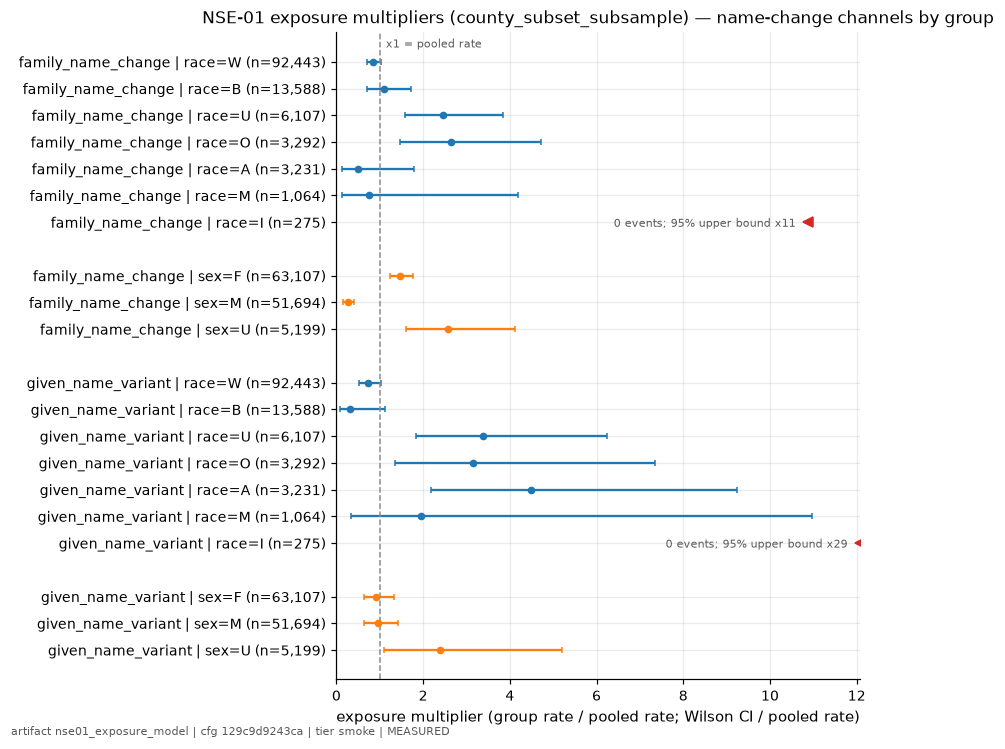

In [17]:
def draw_exposure(ax, df, meta):
    # cap the axis at the widest CI among groups that observed ANY event, so a zero-count
    # group's huge upper bound cannot flatten every readable multiplier against x=0
    cap = 1.1 * float(df.loc[df["k"] > 0, "mult_ci_high"].max())
    y, labels = 0, {}
    for (ch, gcol), block in df.groupby(["channel", "group_col"], sort=True):
        for _, r in block.sort_values("n", ascending=False).iterrows():
            labels[y] = f"{ch} | {gcol}={r['group']} (n={int(r['n']):,})"
            if r["k"] > 0:
                ax.errorbar(r["multiplier"], y,
                            xerr=[[r["multiplier"] - r["mult_ci_low"]],
                                  [r["mult_ci_high"] - r["multiplier"]]],
                            fmt="o", color="C0" if gcol == "race" else "C1",
                            capsize=2, markersize=4)
            else:  # zero events: show the upper bound (clipped to the cap), not a point at 0
                ub = float(r["mult_ci_high"])
                ax.plot(min(ub, cap), y, marker="<", color="C3", markersize=6)
                ax.annotate(f"0 events; 95% upper bound x{ub:.0f}", (min(ub, cap), y),
                            textcoords="offset points", xytext=(-8, -3), fontsize=7,
                            color="0.35", ha="right")
            y += 1
        y += 1  # gap between blocks
    ax.axvline(1.0, color="0.55", linestyle="--", linewidth=1)
    ax.annotate("x1 = pooled rate", (1.0, 1.0), xycoords=("data", "axes fraction"),
                textcoords="offset points", xytext=(4, -4), fontsize=7, color="0.35", va="top")
    ax.set_xlim(0, cap)
    ax.set_yticks(list(labels), list(labels.values()))
    ax.invert_yaxis()
    ax.set_xlabel("exposure multiplier (group rate / pooled rate; Wilson CI / pooled rate)")


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="nse01_exposure_model",
    draw=draw_exposure,
    title=f"NSE-01 exposure multipliers ({AUDIT_SCOPE}) — name-change channels by group",
    figsize=(8.0, 6.8),
)

### Small groups, small power — what these multipliers may claim

At county-subset scope the exposure fit rests on **one county's demographic mix**, and the
printed `n` column is doing the real talking: the large groups' multipliers carry tight
intervals, but the small race groups' intervals span multiples of the pooled rate — a
multiplier of 0 from a zero-event group and a multiplier of 3 from a handful of events are
both compatible with *no group effect at all*. Two rules therefore bind every consumer of
`nse01_exposure_model`: (1) per-group claims from this artifact are **preliminary at any
non-target scope** — notebook 16 (FAIR-01) may use the point multipliers to *construct*
group-correlated noise, but may not cite a county-subset multiplier as a measured disparity
unless its CI excludes 1; (2) the definitive multipliers are the statewide target-tier rerun,
where every group's count grows by roughly the statewide/county ratio and the small-group
intervals tighten accordingly. There is also a substantive confound worth naming: the `U`
(undesignated) groups are not a demographic — they are people who declined to state, a
self-selected population whose elevated volatility may reflect registration recency, not
identity. The exposure model carries codes, not explanations.

In [18]:
# [RUN-IN-TARGET node] definitive statewide NSE-01 audit + exposure fit — real run is tier=target.
if cfg.run.tier == "target":
    print("tier=target: the audit above classified ALL statewide aligned pairs — these prevalence "
          "and exposure tables ARE the definitive NSE-01 numbers; downstream calibration and "
          "FAIR-01 group claims may cite them at face value (CIs permitting).")
else:
    est = "unknown (classify rate not measured)" if classify_secs <= 0 else (
        f"~{6e6 * len(FIELDS) / (len(sub) * len(FIELDS) / classify_secs) / 60:.0f} min at this "
        f"run's {len(sub) * len(FIELDS) / classify_secs:,.0f} cell-diffs/s for ~6M pairs")
    print(f"[RUN-IN-TARGET node] the definitive NSE-01 numbers come from rerunning THESE cells at "
          f"tier=target on the node (statewide aligned pairs; single-core classify {est}). At "
          f"tier={cfg.run.tier} the audit covered '{AUDIT_SCOPE}' "
          f"({len(sub)}/{align_stats['pairs']} pairs of one county subset), so every per-group "
          "multiplier above is preliminary.")

[RUN-IN-TARGET node] the definitive NSE-01 numbers come from rerunning THESE cells at tier=target on the node (statewide aligned pairs; single-core classify ~3 min at this run's 289,340 cell-diffs/s for ~6M pairs). At tier=smoke the audit covered 'county_subset_subsample' (120000/391257 pairs of one county subset), so every per-group multiplier above is preliminary.


## 9. Verdict — scoring the card against the registered numbers

In [19]:
name_changes = prev[(prev["field"].isin(NAME_FIELDS)) & (prev["category"] != "identical")]
max_name_row = name_changes.loc[name_changes["rate"].idxmax()]
street_w = float(prev.loc[(prev["field"] == "street")
                          & (prev["category"] == "wholesale"), "rate"].iloc[0])
p1 = bool(street_w >= P1_DOMINANCE_FACTOR * float(max_name_row["rate"]))

fam_typo_rows = prev.loc[(prev["field"] == "family_name") & (prev["category"] == "typo"), "rate"]
fam_typo = float(fam_typo_rows.iloc[0]) if len(fam_typo_rows) else 0.0
p2 = bool(fam_typo < P2_FAMILY_TYPO_MAX)

fam_sex = exposure[(exposure["channel"] == "family_name_change")
                   & (exposure["group_col"] == "sex")].set_index("group")
p3 = bool(
    {"F", "M"} <= set(fam_sex.index)
    and fam_sex.loc["F", "ci_low"] > fam_sex.loc["M", "ci_high"]
    and fam_sex.loc["F", "multiplier"] >= P3_MULT_RATIO_MIN * fam_sex.loc["M", "multiplier"]
)
checks = {"P1_address_dominance": p1, "P2_family_typo_rare": p2, "P3_sex_exposure": p3}
print(f"P1: street wholesale {street_w:.4%} vs max name change "
      f"{max_name_row['field']}:{max_name_row['category']} {max_name_row['rate']:.4%} "
      f"(x{street_w / max_name_row['rate']:.1f} >= x{P1_DOMINANCE_FACTOR:.0f}): {p1}")
print(f"P2: family_name typo {fam_typo:.4%} < {P2_FAMILY_TYPO_MAX:.0%}: {p2}")
if {"F", "M"} <= set(fam_sex.index):
    print(f"P3: family-name change F {fam_sex.loc['F', 'rate']:.4%} "
          f"[{fam_sex.loc['F', 'ci_low']:.4%}, {fam_sex.loc['F', 'ci_high']:.4%}] vs "
          f"M {fam_sex.loc['M', 'rate']:.4%} "
          f"[{fam_sex.loc['M', 'ci_low']:.4%}, {fam_sex.loc['M', 'ci_high']:.4%}]; "
          f"multipliers F {fam_sex.loc['F', 'multiplier']:.2f} / "
          f"M {fam_sex.loc['M', 'multiplier']:.2f}: {p3}")

P1: street wholesale 1.5217% vs max name change middle_name:wholesale 0.1633% (x9.3 >= x3): True
P2: family_name typo 0.0192% < 1%: True
P3: family-name change F 0.1870% [0.1562%, 0.2239%] vs M 0.0329% [0.0205%, 0.0527%]; multipliers F 1.48 / M 0.26: True


In [20]:
outcome = "CONFIRMED" if all(checks.values()) else "REFUTED"
_ = verdict_box(
    "NSE-01",
    outcome=outcome,
    evidence=(
        f"nse01_channel_prevalence ({AUDIT_SCOPE}, {len(sub)} pairs, window "
        f"{elapsed_years:.2f}y): street:wholesale = {street_w:.4%}, largest name-field change "
        f"category = {max_name_row['field']}:{max_name_row['category']} at "
        f"{max_name_row['rate']:.4%} (dominance x{street_w / max_name_row['rate']:.1f} vs "
        f"pre-stated x{P1_DOMINANCE_FACTOR:.0f}); family_name:typo = {fam_typo:.4%} vs "
        f"pre-stated < {P2_FAMILY_TYPO_MAX:.0%}. nse01_exposure_model: family_name_change by "
        f"sex F multiplier {fam_sex.loc['F', 'multiplier']:.2f} vs M "
        f"{fam_sex.loc['M', 'multiplier']:.2f} with non-overlapping rate CIs = "
        f"{bool(fam_sex.loc['F', 'ci_low'] > fam_sex.loc['M', 'ci_high'])}. Checks: {checks}. "
        f"All rates are two-year CHANGE prevalence under the registered caveat (not entry "
        f"errors), at scope '{AUDIT_SCOPE}' — the statewide target rerun is definitive."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `NSE-01`
>
> **Conjecture** Real two-year record drift is dominated by wholesale replacement of address-bearing fields (people move), not by character-level noise; name fields change rarely and, when they do, predominantly by wholesale replacement (legal name change) rather than typo; and family-name-change exposure is group-correlated (strongly by sex).
>
> **Prediction** P1: street wholesale-change rate exceeds EVERY change category on every name field (given/middle/family) by >= 3x. P2: family_name typo rate < 1% of pairs (expect well under 0.1%). P3: family-name wholesale rate for sex F exceeds sex M with non-overlapping Wilson 95% CIs, and the fitted F exposure multiplier is >= 2x the M multiplier. Scope: changes over two years at this tier's substrate, per the caveat.
>
> **Evidence** nse01_channel_prevalence (county_subset_subsample, 120000 pairs, window 2.00y): street:wholesale = 1.5217%, largest name-field change category = middle_name:wholesale at 0.1633% (dominance x9.3 vs pre-stated x3); family_name:typo = 0.0192% vs pre-stated < 1%. nse01_exposure_model: family_name_change by sex F multiplier 1.48 vs M 0.26 with non-overlapping rate CIs = True. Checks: {'P1_address_dominance': True, 'P2_family_typo_rare': True, 'P3_sex_exposure': True}. All rates are two-year CHANGE prevalence under the registered caveat (not entry errors), at scope 'county_subset_subsample' — the statewide target rerun is definitive.


## What the generator must reproduce

Notebook 05 builds the calibrated dirt machine against exactly these registered targets — this
list is the calibration contract, restated qualitatively (every number lives in the artifacts,
never in prose):

- **The per-field change-category mix** in `nse01_channel_prevalence`, at its measured rates —
  the NSE-02 diff-mix divergence criterion scores a generator's same-entity pairs against this
  table, classified by the *same* audit code the generator never imports.
- **Wholesale replacement as the dominant temporal channel on address roles** — a move channel
  replacing the address block, not per-character noise on street strings.
- **Joint address change** per `nse01_address_cochange`: house number, street, zip, city move
  together; independent per-column corruption is measurably wrong here.
- **Group-correlated exposure** per `nse01_exposure_model`: name-change rates scaled by fitted
  group multipliers (`base_rate × multiplier`, unknown groups defaulting to 1.0), so FAIR-01
  has a substrate in which disparate error exposure exists *by measurement*, not by assumption.
- **What this audit cannot calibrate, said out loud:** entry-error channels (typo, OCR,
  phonetic misspelling) are bounded only from below here — the two-snapshot diff cannot see a
  stable typo. Their base rates in notebook 05 come from generic literature defaults and are
  *labeled* generic-not-measured; NSE-03 then tests whether system rankings even care about
  that distinction.

## What we now know

- **The audit-applicability contract is explicit and checked**: a stable person key (`ncid`,
  audited by MET-05) plus at least two temporal versions (two snapshots, two years). And its
  limit is equally explicit: same-key diffs measure *changes*, not entry errors — the caveat is
  registered in both artifact metas, stamped on the scope column, and repeated at every
  interpretation above.
- **Real two-year dirt is move-shaped, not typo-shaped.** The measured mix (all rates with
  Wilson CIs in `nse01_channel_prevalence`) shows wholesale address replacement dominating
  every name channel; name fields change rarely and mostly wholesale; edit-distance "typos" on
  geographic codes are near-moves in disguise; format drift within one standardized source is
  essentially absent.
- **Address parts change jointly** (`nse01_address_cochange`) — the strongest structural
  argument against independent per-column corruption models.
- **Name-change exposure is group-correlated and now fitted, with stated power limits.**
  `nse01_exposure_model` carries per-group rates, Wilson CIs, and `fit_from_prevalence`
  multipliers by race and sex for both name-change channels; the sex effect on family-name
  change is the headline (scored in the verdict), while small-group race multipliers are
  explicitly preliminary until the statewide `[RUN-IN-TARGET node]` rerun.
- **One package bug found and worked around in-notebook**: the upstream carltonnorthern
  `names.csv` changed to a `name1,has_nickname,name2` triple format that
  `noise.channels.load_lexicon` mis-parses (spurious `has_nickname` variants + a header
  entry); the sanitized lexicon is used everywhere and the workaround is recorded in the
  artifact meta.

## What this changes downstream

- **Notebook 05 (NSE-02)** calibrates its channels against `nse01_channel_prevalence`, its
  move channel against `nse01_address_cochange`, and its exposure wiring against
  `nse01_exposure_model`; its fidelity scoring may not import the generator's own channel code.
- **Notebook 14 (NSE-03)** asks whether rankings survive the difference between this measured
  mix and generic defaults — the question this audit makes askable.
- **Notebook 16 (FAIR-01)** consumes the exposure model under the small-group rules above:
  point multipliers for construction, CI-gated multipliers for claims.
- **Notebook 18** inherits the applicability contract as an adaptation checklist item: no
  stable key + two versions, no noise audit — generic noise, labeled as such.

**Artifacts registered** (exact names): `nse01_channel_prevalence`, `nse01_exposure_model` —
plus the supporting `nse01_address_cochange` and the immutable card `card_NSE-01`.

In [21]:
print(f"notebook wall-clock: {time.time() - NB_T0:.0f}s")

notebook wall-clock: 8s
